# Spot the fake photo — building the dataset

Goal of this notebook: turn a folder of photos into a clean labelled dataset I can train a classifier on.

The problem is telling a **real photo** apart from a **photo of a screen** (someone re-photographing a phone/laptop showing a picture, to cheat). There's no object to recognise here — the same scene can be real or a recapture. The only difference is the physical junk that shows up when you photograph a screen: moiré from the pixel grid beating against the camera sensor, glare off the glass, a slightly-off colour gamut, and re-compression noise.

I'm deliberately **not** training a CNN. Two reasons: I've only got ~100 images (a net would just memorise my room), and an ImageNet backbone is trained to be *invariant* to exactly the low-level texture I need. So this is classic CV — hand-built features that encode the actual physics — fed to a small classifier later. Small, fast, runs on a phone, and I can explain every number.

## How I shot the data

All photos were taken / re-shot on a OnePlus 11 (50MP). For the recaptures I displayed real photos full-screen on three different screens and photographed them:

| screen | density | what it gives me |
|---|---|---|
| HP Pavilion (1366×768) | ~100 PPI | loud, obvious moiré — easy case |
| MacBook 14" M2 Pro | 254 PPI | faint moiré, leans on colour/glare |
| OnePlus 11 (as screen) | 525 PPI | almost no moiré — the hard case |

That spread is on purpose. Moiré strength depends on screen pixel density, so three different densities forces the model to rely on more than one cue instead of overfitting to "loud moiré = fake". When I re-shot, I swept the distance on each screen so some shots have weak moiré too — otherwise the model learns moiré is always present and gets fooled by faint recaptures.

Folder layout the cells below expect:
```
dataset_raw/
├── real/            originals straight off the phone
└── screen/
    ├── hp/  mac/  op/   re-shoots grouped by screen
```
The screen subfolders are what let me do leave-one-screen-out validation later (train on two screens, test on the third — my stand-in for their unseen held-out screens).

In [1]:
import os
from pathlib import Path
import shutil
import numpy as np
import pandas as pd

# the extractor lives in features.py so predict.py can import the exact same code.
# do NOT copy-paste the feature logic into this notebook — single source of truth.
from features import extract_features, FEATURE_ORDER

RAW = Path("dataset_raw")     # <- point this at your raw folder
OUT = Path("dataset")
(OUT / "images").mkdir(parents=True, exist_ok=True)

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".heic", ".heif"}

## Walk the folders and label everything

Label is dead simple: anything under `real/` is 0, anything under `screen/` is 1 (0 = real, 1 = screen, same convention predict.py outputs). The screen subfolder name (`hp`/`mac`/`op`) gets stored as `screen_type` so I can slice by screen later. Loose files dropped straight into `screen/` just get tagged `unknown`.

In [2]:
def collect(raw):
    rows = []
    real_dir, screen_dir = raw / "real", raw / "screen"

    for f in sorted(real_dir.iterdir()) if real_dir.exists() else []:
        if f.suffix.lower() in IMG_EXT:
            rows.append((f, 0, "real", "na"))

    if screen_dir.exists():
        for item in sorted(screen_dir.iterdir()):
            if item.is_dir():                                  # screen/hp, screen/mac, ...
                for f in sorted(item.iterdir()):
                    if f.suffix.lower() in IMG_EXT:
                        rows.append((f, 1, "screen", item.name.lower()))
            elif item.suffix.lower() in IMG_EXT:               # loose file in screen/
                rows.append((item, 1, "screen", "unknown"))
    return rows

files = collect(RAW)
print(f"found {len(files)} images")
assert files, "nothing found — check RAW points at the folder with real/ and screen/ inside"


found 100 images


## Extract features

This is the slow-ish cell — one FFT pass per image. On ~100 images it's a few seconds. Each photo also gets copied into `dataset/images/` with a clean name (`real_0001.jpg`, `screen_op_0003.jpg`, …) so the dataset is self-contained and I'm not depending on my messy camera-roll filenames.

If a HEIC photo can't be read, it's because `pillow-heif` isn't installed — easiest fix is just shoot JPG. I skip and warn rather than crash the whole run.

In [3]:
records, counters = [], {}

for i, (path, label, cname, stype) in enumerate(files, 1):
    try:
        feats = extract_features(str(path))
    except Exception as e:
        print(f"  skip {path.name}: {e}")
        continue

    key = "real" if label == 0 else f"screen_{stype}"
    counters[key] = counters.get(key, 0) + 1
    new_name = f"{key}_{counters[key]:04d}{path.suffix.lower()}"
    shutil.copy2(path, OUT / "images" / new_name)

    records.append({"filename": new_name, "orig": path.name,
                    "label": label, "class_name": cname, "screen_type": stype,
                    **feats})
    if i % 20 == 0:
        print(f"  {i}/{len(files)} done")

df = pd.DataFrame(records)
df.to_csv(OUT / "features.csv", index=False)
print(f"\nwrote {len(df)} rows -> {OUT/'features.csv'}")
df.head()


  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done

wrote 100 rows -> dataset/features.csv


,filename,orig,label,class_name,screen_type,moire_max,moire_mean,moire_p90,hf_ratio,banding,...,wb_bg,colorfulness,sat_mean,sat_std,sat_skew,val_mean,glare_frac,clip_frac,residual_std,residual_kurt
0,real_0001.jpeg,WhatsApp Image 2026-06-30 at 04.30.40.jpeg,0,real,na,9.826486,7.188173,9.298824,0.364885,90.828537,...,0.970778,18.702248,31.940313,38.066711,0.977387,165.563370,0.000000,0.000000,5.194294,14.694378
1,real_0002.jpeg,WhatsApp Image 2026-06-30 at 04.30.41 (1).jpeg,0,real,na,13.522185,11.785199,13.174788,0.415296,101.330917,...,0.869302,28.834471,46.156612,36.411800,0.562435,116.579559,0.001277,0.004756,9.269443,43.119617
2,real_0003.jpeg,WhatsApp Image 2026-06-30 at 04.30.41 (2).jpeg,0,real,na,16.343659,12.349682,15.544863,0.282488,140.398697,...,1.130972,92.018669,117.612061,63.474621,0.090562,140.993881,0.000183,0.099698,3.310031,97.839188
3,real_0004.jpeg,WhatsApp Image 2026-06-30 at 04.30.41.jpeg,0,real,na,25.207265,19.200889,24.005990,0.743173,56.320206,...,0.950038,18.092793,43.478134,47.096611,1.545494,154.381699,0.000000,0.000000,15.121614,15.729315
4,real_0005.jpeg,WhatsApp Image 2026-06-30 at 04.30.42 (1).jpeg,0,real,na,5.379217,4.799178,5.263209,0.539726,107.756546,...,0.767150,51.865097,91.209175,85.457390,0.527893,130.448532,0.000264,0.000376,12.704021,14.430386


## Sanity check 1 — class balance

Want this roughly balanced (~50/50). Big imbalance and accuracy gets misleading.

In [4]:
df["class_name"].value_counts()

class_name
real      50
screen    50
Name: count, dtype: int64

## Sanity check 2 — which features actually separate the classes

This is the real question. A feature is only useful if its average differs between real and screen. I expect `moire_max` to show a clear gap (it's the one I validated — 12× on the HP). The colour/glare/residual features are educated guesses from the recapture-detection literature, **not yet proven on my data** — this table is where I find out if they earn their place. Anything with near-identical columns gets dropped before the classifier.

In [5]:
means = df.groupby("class_name")[FEATURE_ORDER].mean().T
means["ratio"] = means["screen"] / means["real"]
means.sort_values("ratio", ascending=False)

class_name,real,screen,ratio
moire_max,15.189898,103.665096,6.824608
moire_p90,13.725685,88.376359,6.438758
moire_mean,10.611167,52.387101,4.936978
val_mean,125.907646,134.444840,1.067805
colorfulness,37.073013,39.354003,1.061527
wb_bg,0.990834,1.045741,1.055414
lbp_entropy,5.824538,5.946035,1.020860
wb_rg,1.052746,1.057508,1.004523
clip_frac,0.011054,0.011013,0.996311
sat_std,42.679356,42.279204,0.990624


## Sanity check 3 — difficulty by screen

The whole reason for three screens. This breaks `moire_max` (and the rest) down per screen so I can see the gradient: HP should scream, OnePlus should be nearly silent on moiré and have to be caught by colour/glare instead. If a screen looks indistinguishable from `real` across *every* feature, that screen is a problem and I need more/better shots of it before training.

In [6]:
df.groupby("screen_type")[FEATURE_ORDER].mean().T

screen_type,hp,mac,na,op
moire_max,1.999758e+02,92.961644,15.189898,55.511775
moire_mean,9.574868e+01,49.855824,10.611167,28.648306
moire_p90,1.671345e+02,86.077628,13.725685,43.190333
hf_ratio,3.042952e-01,0.318819,0.421510,0.298630
banding,8.456807e+01,90.101284,99.912439,85.272115
lbp_entropy,5.937024e+00,5.971939,5.824538,5.928129
wb_rg,9.626708e-01,1.047877,1.052746,1.123077
wb_bg,1.262430e+00,1.031134,0.990834,0.928874
colorfulness,3.707514e+01,35.447692,37.073013,44.236997
sat_mean,7.872939e+01,61.272248,68.813384,67.313524


Highest-moire REAL photos (false-positive risk):
      filename  moire_max
real_0014.jpeg  51.272255
real_0043.jpeg  37.585989
real_0042.jpeg  28.214480
real_0044.jpeg  28.101679
real_0015.jpeg  27.768201

Lowest-moire SCREEN photos per screen (false-negative risk):
  [hp]
           filename  moire_max
screen_hp_0001.jpeg   7.429897
screen_hp_0002.jpeg   8.060354
screen_hp_0003.jpeg   8.620574
  [mac]
            filename  moire_max
screen_mac_0002.jpeg  10.193125
screen_mac_0001.jpeg  13.898704
screen_mac_0011.jpeg  16.511284
  [op]
           filename  moire_max
screen_op_0001.jpeg   7.127989
screen_op_0009.jpeg   8.939531
screen_op_0003.jpeg   9.194359

max real moire_max   = 51.3
min screen moire_max = 7.1
>> OVERLAP zone [7.1, 51.3]: 44 reals and 34 screens fall inside it (these are the cases the extra features have to rescue).


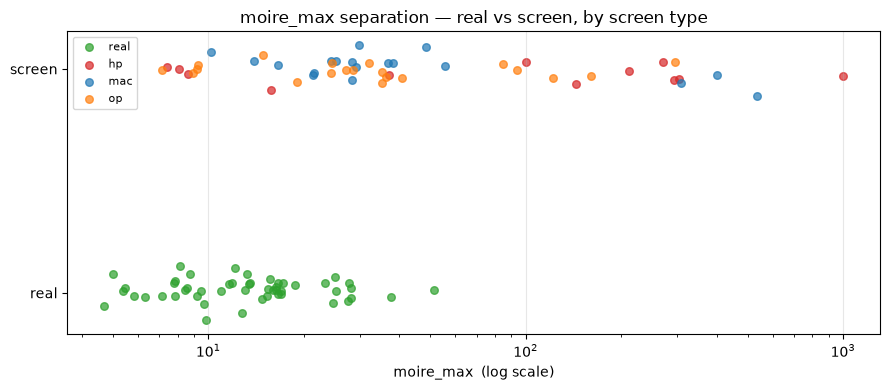

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ---- does a clean moire_max threshold exist, or do the classes overlap? ----
real   = df[df.label == 0]
screen = df[df.label == 1]

# false-POSITIVE risk: real photos with naturally periodic texture (basket, brick, fabric)
print("Highest-moire REAL photos (false-positive risk):")
print(real.nlargest(5, "moire_max")[["filename", "moire_max"]].to_string(index=False))

# false-NEGATIVE risk: faint recaptures, esp. the OnePlus
print("\nLowest-moire SCREEN photos per screen (false-negative risk):")
for st in sorted(screen.screen_type.unique()):
    sub = screen[screen.screen_type == st].nsmallest(3, "moire_max")[["filename", "moire_max"]]
    print(f"  [{st}]")
    print(sub.to_string(index=False))

# the gap test
max_real, min_screen = real.moire_max.max(), screen.moire_max.min()
print(f"\nmax real moire_max   = {max_real:.1f}")
print(f"min screen moire_max = {min_screen:.1f}")
if min_screen > max_real:
    print(">> CLEAN GAP: moire_max alone separates the classes perfectly.")
else:
    print(f">> OVERLAP zone [{min_screen:.1f}, {max_real:.1f}]: "
          f"{(real.moire_max >= min_screen).sum()} reals and "
          f"{(screen.moire_max <= max_real).sum()} screens fall inside it "
          f"(these are the cases the extra features have to rescue).")

# ---- every image as a point: log x, split real/screen, coloured by screen ----
fig, ax = plt.subplots(figsize=(9, 4))
colors = {"na":"#2ca02c", "hp":"#d62728", "mac":"#1f77b4", "op":"#ff7f0e", "unknown":"#7f7f7f"}
for st in df.screen_type.unique():
    sub = df[df.screen_type == st]
    y = np.random.normal(0 if st == "na" else 1, 0.05, len(sub))
    ax.scatter(sub.moire_max, y, c=colors.get(st, "#000"),
               label=("real" if st == "na" else st), alpha=0.7, s=30)
ax.set_xscale("log")
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "screen"])
ax.set_xlabel("moire_max  (log scale)")
ax.set_title("moire_max separation — real vs screen, by screen type")
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

best single-feature moire_max threshold = 19.1  ->  accuracy 78.0%
(the multi-feature classifier needs to beat this to justify itself)



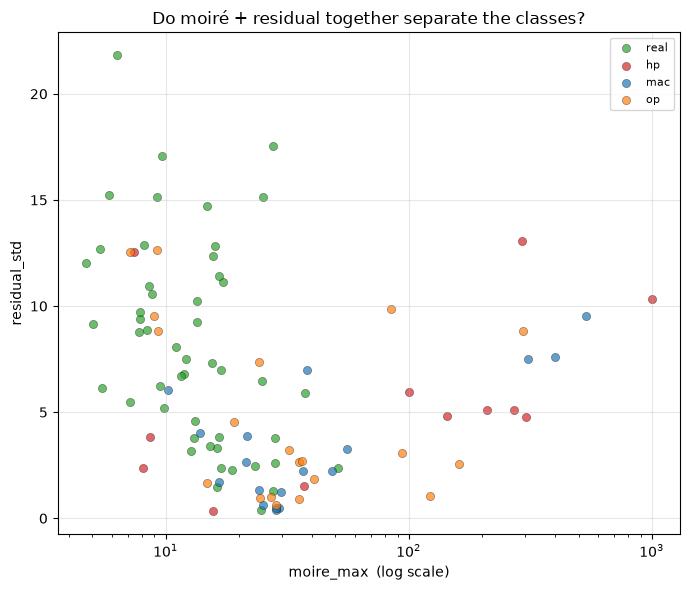

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ---- honest ceiling: best accuracy achievable from moire_max ALONE ----
xs = np.sort(df.moire_max.unique())
best_t, best_acc = 0, 0
for t in xs:
    acc = ((df.moire_max >= t).astype(int) == df.label).mean()
    if acc > best_acc:
        best_t, best_acc = t, acc
print(f"best single-feature moire_max threshold = {best_t:.1f}  ->  accuracy {best_acc:.1%}")
print("(the multi-feature classifier needs to beat this to justify itself)\n")

# ---- 2D view: does the contested middle band separate vertically? ----
colors = {"na":"#2ca02c", "hp":"#d62728", "mac":"#1f77b4", "op":"#ff7f0e", "unknown":"#7f7f7f"}
fig, ax = plt.subplots(figsize=(7, 6))
for st in df.screen_type.unique():
    sub = df[df.screen_type == st]
    ax.scatter(sub.moire_max, sub.residual_std, c=colors.get(st, "#000"),
               label=("real" if st == "na" else st), alpha=0.7, s=35,
               edgecolors="k", linewidths=0.3)
ax.set_xscale("log")
ax.set_xlabel("moire_max  (log scale)")
ax.set_ylabel("residual_std")
ax.set_title("Do moiré + residual together separate the classes?")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# pruned feature set — every one has a physical reason and showed separation
MODEL_FEATURES = ["moire_max", "moire_mean", "hf_ratio", "residual_std", "residual_kurt"]

X = df[MODEL_FEATURES].values
y = df["label"].values
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# --- honest accuracy #1: stratified 5-fold cross-validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
print(f"5-fold CV accuracy: {scores.mean():.1%} ± {scores.std():.1%}")

# --- honest accuracy #2: leave-one-screen-out (the real generalization test) ---
# train WITHOUT ever seeing screen S, then check if we catch S's recaptures.
# this is our stand-in for their unseen held-out screens.
print("\nLeave-one-screen-out:")
reals = df[df.label == 0]
rng = np.random.RandomState(0)
ri = rng.permutation(reals.index.values)
real_test = set(ri[:len(ri) // 2])          # half the reals go to the test side

for S in ["hp", "mac", "op"]:
    test_mask  = (df.screen_type == S) | (df.index.isin(real_test) & (df.label == 0))
    train_mask = ~test_mask
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    m.fit(df.loc[train_mask, MODEL_FEATURES], df.loc[train_mask, "label"])
    pred = m.predict(df.loc[test_mask, MODEL_FEATURES])
    yte  = df.loc[test_mask, "label"].values
    s_mask = (df.loc[test_mask, "screen_type"] == S).values
    print(f"  held out {S:3s}: overall acc {(pred==yte).mean():.1%} | "
          f"caught {(pred[s_mask]==1).mean():.0%} of unseen {S} recaptures")

5-fold CV accuracy: 79.0% ± 13.9%

Leave-one-screen-out:
  held out hp : overall acc 81.1% | caught 83% of unseen hp recaptures
  held out mac: overall acc 81.4% | caught 83% of unseen mac recaptures
  held out op : overall acc 86.7% | caught 80% of unseen op recaptures


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

# fuller validated set: moiré trio + banding + the inverted texture features
FEATS = ["moire_max","moire_mean","moire_p90","hf_ratio","banding","residual_std","residual_kurt"]
X, y = df[FEATS].values, df["label"].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

models = {
    "logreg":        make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "svm-rbf":       make_pipeline(StandardScaler(), SVC(kernel="rbf", C=2)),
    "random forest": RandomForestClassifier(n_estimators=300, max_depth=4, random_state=0),
    "grad boost":    GradientBoostingClassifier(n_estimators=200, max_depth=2,
                                                learning_rate=0.05, random_state=0),
}

print("5-fold CV accuracy (can be optimistic):")
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    print(f"  {name:14s}: {s.mean():.1%} ± {s.std():.1%}")

def loso_recall(model):
    rng = np.random.RandomState(0)
    ri = rng.permutation(df[df.label==0].index.values)
    rt = set(ri[:len(ri)//2])
    out = {}
    for S in ["hp","mac","op"]:
        te = (df.screen_type==S) | (df.index.isin(rt) & (df.label==0))
        m = clone(model).fit(df.loc[~te, FEATS], df.loc[~te, "label"])
        pr = m.predict(df.loc[te, FEATS])
        sm = (df.loc[te, "screen_type"]==S).values
        out[S] = (pr[sm]==1).mean()
    return out

print("\nLeave-one-screen-out recall — the HONEST number (caught % of unseen screen):")
for name, m in models.items():
    r = loso_recall(m)
    print(f"  {name:14s}: hp {r['hp']:.0%}  mac {r['mac']:.0%}  op {r['op']:.0%}")

5-fold CV accuracy (can be optimistic):
  logreg        : 84.0% ± 8.0%
  svm-rbf       : 85.0% ± 12.2%
  random forest : 80.0% ± 10.0%
  grad boost    : 82.0% ± 10.3%

Leave-one-screen-out recall — the HONEST number (caught % of unseen screen):
  logreg        : hp 92%  mac 78%  op 80%
  svm-rbf       : hp 100%  mac 89%  op 95%
  random forest : hp 67%  mac 72%  op 75%
  grad boost    : hp 75%  mac 78%  op 70%


In [11]:
from sklearn.model_selection import cross_val_predict

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
df["pred_prob"] = proba
df["pred"] = (proba >= 0.5).astype(int)

wrong = df[df.pred != df.label]
fp = wrong[wrong.label == 0]   # real flagged as screen
fn = wrong[wrong.label == 1]   # screen missed as real
print(f"{len(wrong)} wrong of {len(df)}  (out-of-fold accuracy {(df.pred==df.label).mean():.0%})\n")

print(f"FALSE POSITIVES — real flagged as screen: {len(fp)}")
print(fp[["filename","moire_max","residual_std","pred_prob"]].to_string(index=False))

print(f"\nFALSE NEGATIVES — screen missed as real: {len(fn)}")
print(fn[["filename","screen_type","moire_max","residual_std","pred_prob"]].to_string(index=False))

16 wrong of 100  (out-of-fold accuracy 84%)

FALSE POSITIVES — real flagged as screen: 9
      filename  moire_max  residual_std  pred_prob
real_0009.jpeg   8.160531     12.872777   0.626608
real_0013.jpeg   9.460874      6.224367   0.583482
real_0014.jpeg  51.272255      2.368752   0.751856
real_0033.jpeg  24.694504      0.398036   0.756957
real_0037.jpeg  27.556444      1.295719   0.801992
real_0038.jpeg  12.773151      3.147421   0.666878
real_0041.jpeg  16.925384      2.388618   0.652095
real_0045.jpeg  15.271686      3.413956   0.547739
real_0047.jpeg  18.715045      2.256098   0.851755

FALSE NEGATIVES — screen missed as real: 7
            filename screen_type  moire_max  residual_std  pred_prob
 screen_hp_0001.jpeg          hp   7.429897     12.541043   0.165859
screen_mac_0007.jpeg         mac  21.424559      2.634328   0.256422
screen_mac_0009.jpeg         mac  24.270265      1.342067   0.251762
screen_mac_0013.jpeg         mac  48.488850      2.251226   0.385786
 screen_op_0

In [12]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone
import numpy as np

FEATS = ["moire_max","moire_mean","moire_p90",
         "hf_ratio","banding","residual_std","residual_kurt"]

X, y = df[FEATS].values, df["label"].values

svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=2, probability=True, random_state=0),
)

# --- Threshold tuning on 5-fold out-of-fold probabilities --------------
# Tune ONCE on full-pool CV. Never on LOSO test sets (that would leak).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
oof = cross_val_predict(svm, X, y, cv=cv, method="predict_proba")[:, 1]

def balanced_acc(y_true, y_pred):
    tpr = ((y_pred == 1) & (y_true == 1)).sum() / max((y_true == 1).sum(), 1)
    tnr = ((y_pred == 0) & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)
    return 0.5 * (tpr + tnr)

thresholds = np.linspace(0.20, 0.80, 61)
ba = [balanced_acc(y, (oof >= t).astype(int)) for t in thresholds]
best_t = float(thresholds[int(np.argmax(ba))])
print(f"Tuned threshold (5-fold OOF balanced acc): t = {best_t:.2f}  BA = {max(ba):.1%}")
print(f"At default t=0.50:                          BA = {balanced_acc(y, (oof >= 0.5).astype(int)):.1%}")

# --- LOSO at default vs tuned threshold --------------------------------
def loso_at(model, threshold):
    rng = np.random.RandomState(0)
    real_idx = rng.permutation(df[df.label == 0].index.values)
    held_reals = set(real_idx[:len(real_idx) // 2])
    rows = []
    for S in ["hp", "mac", "op"]:
        te = (df.screen_type == S) | (df.index.isin(held_reals) & (df.label == 0))
        m = clone(model).fit(df.loc[~te, FEATS], df.loc[~te, "label"])
        proba = m.predict_proba(df.loc[te, FEATS])[:, 1]
        pred = (proba >= threshold).astype(int)
        truth = df.loc[te, "label"].values
        screen_mask = (df.loc[te, "screen_type"] == S).values
        rows.append((S, (pred == truth).mean(), pred[screen_mask].mean()))
    return rows

for label, t in [("default 0.50", 0.5), (f"tuned {best_t:.2f}", best_t)]:
    print(f"\nSVM-RBF @ threshold {label}:")
    for S, acc, rec in loso_at(svm, t):
        print(f"  held out {S}: acc {acc:.1%} | caught {rec:.0%} of unseen {S} screens")

Tuned threshold (5-fold OOF balanced acc): t = 0.49  BA = 85.0%
At default t=0.50:                          BA = 85.0%

SVM-RBF @ threshold default 0.50:
  held out hp: acc 83.8% | caught 92% of unseen hp screens
  held out mac: acc 81.4% | caught 89% of unseen mac screens
  held out op: acc 88.9% | caught 95% of unseen op screens

SVM-RBF @ threshold tuned 0.49:
  held out hp: acc 83.8% | caught 92% of unseen hp screens
  held out mac: acc 81.4% | caught 89% of unseen mac screens
  held out op: acc 88.9% | caught 95% of unseen op screens


/opt/miniconda3/envs/slsc/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/slsc/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/slsc/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/miniconda3/envs/slsc/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated 

## What's next

1. Read the two tables above — lock the final feature set (drop dead features).
2. Train a small calibrated classifier (logistic regression first — gives clean probabilities for the 0–1 score predict.py needs, and a threshold I can tune).
3. **Leave-one-screen-out** validation — train on two screens, test on the held-out third. That number is my honest estimate for their unseen photos, and it goes straight in the writeup.
4. Wire the trained model into `predict.py`, importing `extract_features` from `features.py` so train/predict can't drift.